<a href="https://colab.research.google.com/github/Dhruv152805/Caption-Generator/blob/main/nptel2_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

california_path = "https://raw.githubusercontent.com/Armagaan/noc26_cs86/refs/heads/main/data/california_housing.csv"
df = pd.read_csv(california_path)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
meann = df["MedInc"].mean()
mediann = df["MedInc"].median()
modee = df["MedInc"].mode()
print(meann)
print(mediann)
print(modee)

3.8706710029069766
3.5347999999999997
0     3.1250
1    15.0001
Name: MedInc, dtype: float64


In [4]:
print(f"MedInc - Mean: {meann:.2f}, Median: {mediann:.2f}, Mode: {modee[0]:.2f}")

MedInc - Mean: 3.87, Median: 3.53, Mode: 3.12


In [5]:
print(f"MedInc - Mean: {meann:.2f}, Median: {mediann:.2f}, Mode: {modee[1]:.2f}")

MedInc - Mean: 3.87, Median: 3.53, Mode: 15.00


In [6]:
a = df["HouseAge"]
range = a.max() -  a.min()
a.var()
a.std()
print(a.var())
print(range)
print(a.std())

158.39626040778117
51.0
12.585557612111637


the above one is how i wrote

In [7]:
house_age = df['HouseAge']
age_range = house_age.max() - house_age.min()
age_var = house_age.var()
age_std = house_age.std()

print(f"HouseAge - Range: {age_range}, Variance: {age_var:.2f}, Std Dev: {age_std:.2f}")

HouseAge - Range: 51.0, Variance: 158.40, Std Dev: 12.59


In [8]:
std_Inc = df["MedInc"].std()
std_pop = df["Population"].std()
cv = (std_Inc / df["MedInc"].mean())*100
cv_pop = (std_pop / df["Population"].mean())*100
print(cv)
print(cv_pop)
print(f"{std_Inc:.4f}, {std_pop:.4f}")

49.082490258625874
79.44444736711425
1.8998, 1132.4621


In [19]:
import numpy as np
q1,q2,q3 = np.percentile(df["AveRooms"],[25, 50, 75])
iqr = q3 -q1
print(f"AveRooms - q1:{q1:.4f}, q2:{q2:.4f}, q3:{q3:.4f} , IQR: {iqr:.2f})")

AveRooms - q1:4.4407, q2:5.2291, q3:6.0524 , IQR: 1.61)


In [27]:
MedHouse_mean = df["MedHouseVal"].mean()
MedHouse_Std = df["MedHouseVal"].std()

print(f"(MedHouse_mean: {df["MedHouseVal"].mean():.4f}, MedHouse_Std: {df["MedHouseVal"].std():.4f})")
lower , upper = MedHouse_mean - 2*MedHouse_Std , MedHouse_mean + 2*MedHouse_Std
print(f"(lower: {lower:.4f}, upper: {upper:.4f})")
 #method1
mask = (df['MedHouseVal'] >= lower) & (df['MedHouseVal'] <= upper)

within_2std = df[mask]
percentage = (len(within_2std) / len(df)) * 100

print(f"Percentage within 2 Std Dev: {percentage:.2f}% (Chebyshev requires > 75%)")

(MedHouse_mean: 2.0686, MedHouse_Std: 1.1540)
(lower: -0.2394, upper: 4.3765)
Percentage within 2 Std Dev: 93.30% (Chebyshev requires > 75%)


In [28]:
#method2
mask2 = df['MedHouseVal'].between(lower, upper)

within_2std = df[mask2]
percentage = (len(within_2std) / len(df)) * 100

print(f"Percentage within 2 Std Dev: {percentage:.2f}% (Chebyshev requires > 75%)")

Percentage within 2 Std Dev: 93.30% (Chebyshev requires > 75%)


In [29]:
from scipy.stats import skew
pop_skew = skew(df["Population"])
print(pop_skew)

4.93549950885852


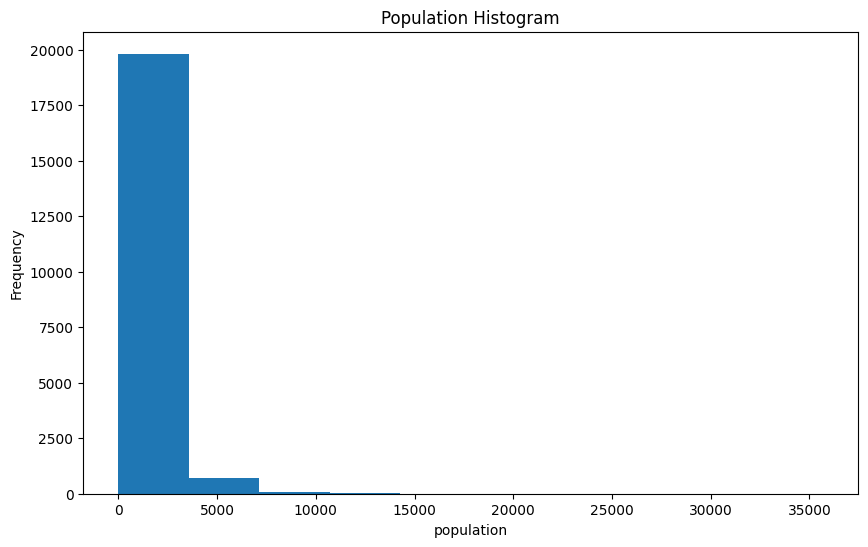

In [41]:
df["Population"].plot(
    kind = "hist",
    xlabel= "population",
    title= "Population Histogram",
    figsize= (10,6)
)
plt.show()

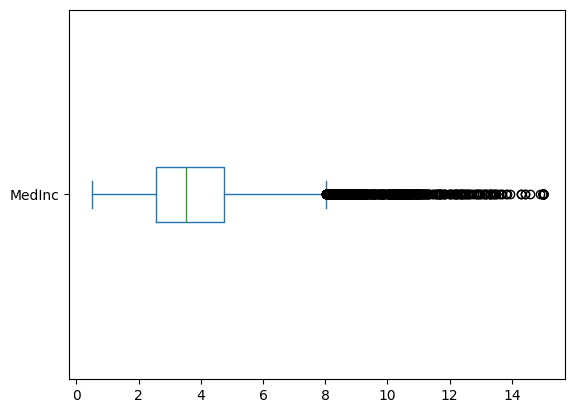

In [43]:
df["MedInc"].plot(
    kind = "box",
    vert=False,
)
plt.show()